# Differential-adhesion cell sorting on a closed spherical epithelium

A 2.5-D **closed** epithelial sheet of ~200 cells wrapped onto a sphere, carrying two
cell types (`A` and `B`) mixed 50:50 at random. Junction tension is set by the *identity
of the pair of cells the junction separates*: heterotypic (`A|B`) interfaces are held at
a higher line tension than homotypic (`A|A`, `B|B`) ones. The tissue can then lower its
energy by shrinking the mixed interface, and the two populations sort out — the classic
differential-adhesion / differential-interfacial-tension picture of cell sorting.

This notebook builds the whole experiment step by step:

1. generate the spherical mesh and label the cells 50:50,
2. write the `EulerSolver` configuration, parameter by parameter,
3. write the `DifferentialAdhesion` configuration,
4. wire both into a `process_bigraph` composite **spec**, and draw the bigraph,
5. run it,
6. render and display the movie,
7. quantify the sorting with the **sorting index**
   $S(t) = N_\mathrm{homotypic}/N_\mathrm{total}$.

A **control** run — identical in every respect except that the two tensions are equal —
is run alongside, so the sorting index is measured against a baseline rather than
against an assumption.

Run from the repo's **`vivarium-tyssue` conda env** (the `.venv` / `uv` setup is broken),
with this directory as the working directory. The GIF needs ImageMagick's `magick` on
`PATH`.

## The model

### Mechanics — a closed 2.5-D vertex model

Cells are polygonal faces $\alpha$ on a closed surface embedded in 3-D, with area
$A_\alpha$ and perimeter $P_\alpha$, meeting at junctions $\langle ij\rangle$ of length
$\ell_{ij}$. The surface encloses a lumen of volume $V_\mathrm{lum}$. The mechanical
energy is

$$
E \;=\; \sum_{\alpha}\left[\frac{K_A}{2}\left(A_\alpha - A_0\right)^{2}
      \;+\; \frac{K_P}{2}\left(P_\alpha - P_0\right)^{2}\right]
  \;+\; \sum_{\langle ij\rangle} \Lambda_{ij}\,\ell_{ij}
  \;+\; \frac{K_V}{2}\left(V_\mathrm{lum} - V_0\right)^{2}
  \;+\; \sum_{i}\frac{K_S}{2}\left(\delta_i - \delta_0\right)^{2},
$$

one term per tyssue effector requested here:

| term | effector | parameters (dataframe) |
|---|---|---|
| $\tfrac{K_A}{2}(A_\alpha-A_0)^2$ | `FaceAreaElasticity` | `area_elasticity`, `prefered_area` (`face_df`) |
| $\tfrac{K_P}{2}(P_\alpha-P_0)^2$ | `PerimeterElasticity` | `perimeter_elasticity`, `prefered_perimeter` (`face_df`) |
| $\Lambda_{ij}\ell_{ij}$ | `LineTension` | `line_tension` (`edge_df`) |
| $\tfrac{K_V}{2}(V_\mathrm{lum}-V_0)^2$ | `LumenVolumeElasticity` | `lumen_vol_elasticity`, `lumen_prefered_vol` (`settings`) |
| $\tfrac{K_S}{2}(\delta_i-\delta_0)^2$ | `SurfaceElasticity` | `surface_elasticity`, `prefered_deviation` (`vert_df`) |

The lumen term is what makes the geometry **closed** rather than merely curved:
`ClosedSheetGeometry.update_all` computes the enclosed volume into
`sheet.settings["lumen_vol"]` on every geometry update, and the elastic penalty on it
is what stops the vesicle collapsing under its own surface tension.

The last term is the surface smoother. $\delta_i$ is how far vertex $i$ sits from the
**centroid of its neighbouring vertices** — `vert_df["dev_length"]` — so pulling it back
toward $\delta_0$ is Laplacian ("umbrella") smoothing, and it is what resists a cell
everting into a spike. `SurfaceElasticity` *reads* that column but does not compute it,
and in stock tyssue only the cylinder geometry writes it; this repo adds
`ClosedSheetVertDeviationGeometry` (`vivarium_tyssue/geometry/vert_deviation.py`) —
`ClosedSheetGeometry` plus a vectorised one-ring deviation update — so a closed sheet can
carry the term. **It is a genuine trade-off against the sorting, not a free improvement;
the sweep at the end of the notebook measures the cost.**

Vertices move in the overdamped limit,

$$\eta\,\frac{\mathrm{d}\mathbf r_i}{\mathrm{d}t} \;=\; -\frac{\partial E}{\partial \mathbf r_i},$$

integrated by an explicit forward-Euler step of size $\Delta t$ (`EulerSolver`).
Junctions shorter than $\ell_\mathrm{min}$ are merged and the resulting rank-4 vertices
detach again (`auto_reconnect`), giving **T1 neighbour exchanges** — without which no
amount of tension can sort anything, because cells could never change neighbours.

### Differential adhesion

Writing $\tau(\alpha)$ for the type of cell $\alpha$, the junction between cells $a$ and
$b$ carries

$$
\Lambda_{ij} \;=\;
\begin{cases}
\Lambda_\mathrm{homo}, & \tau(a) = \tau(b)\\[2pt]
\Lambda_\mathrm{het},  & \tau(a) \neq \tau(b)
\end{cases}
\qquad\text{with}\qquad \Lambda_\mathrm{het} > \Lambda_\mathrm{homo}.
$$

Higher tension on a mixed interface means less adhesion across it, so the tissue pays
energy per unit length of `A|B` boundary and minimises that length.

### The sorting index

$$
S(t) \;=\; \frac{N_\mathrm{homotypic}(t)}{N_\mathrm{homotypic}(t) + N_\mathrm{heterotypic}(t)}.
$$

For a random 50:50 mixture $S \approx 0.5$; fully sorted into two caps only the single
`A|B` boundary ring is heterotypic, so $S \to 1$.

*On half-edges:* tyssue stores each junction as two oriented half-edges, one per adjacent
face, and the line-tension energy is $\tfrac12\Lambda\ell$ per half-edge — so a junction
whose two half-edges both carry $\Lambda$ contributes $\Lambda\ell$, as written above.
Both half-edges of a junction are always in the same class, so counting half-edges and
counting junctions give the identical ratio.

## Where the model lives — a process, and a behavior

The mechanics are the stock `EulerSolver`, **unmodified**. The differential adhesion is
added the way every other regulation in this repo is added — a process that writes into
the shared `Behaviors` store, which the solver drains on its next step:

* **`DifferentialAdhesion`** (`vivarium_tyssue/processes/regulations.py`) — a `Process`
  whose only output port is `behaviors`. It ships the two tension *values* and the name
  of the type column. It is a sibling of `StochasticLineTension` and
  `AnisotropicTension`.
* **`differential_adhesion`** (`vivarium_tyssue/behaviors/behaviors.py`) — the behavior
  the solver's `EventManager` executes on the live epithelium. It classifies **every
  junction from the current topology** and writes `edge_df["line_tension"]`.

The classification deliberately lives in the *behavior* rather than in the process.
Which junctions are heterotypic is a property of the mesh as it stands at the moment the
tension is applied, and the mesh a process sees through its `datasets` input is the mesh
from *before* this step's T1 transitions. A T1 rewires a junction so that it separates a
different pair of cells; a tension table computed once at $t=0$ and keyed by edge id
would then put homotypic tension on a freshly-created heterotypic interface, and the
sorting would quietly stall. Re-deriving the classification from the live
`srce`/`trgt`/`face` topology on every step is what keeps that from happening — and it
is also what makes the same behavior correct if divisions or extrusions are added later.

## Setup

In [1]:
from __future__ import annotations

import sys
import time
import warnings
from copy import deepcopy
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

HERE = Path.cwd()
assert HERE.name == "differential_adhesion", (
    f"run this notebook with Experiments/differential_adhesion as the working "
    f"directory (currently {HERE})"
)
REPO = HERE.parents[1]
sys.path.insert(0, str(REPO))                    # vivarium_tyssue
sys.path.insert(0, str(REPO / "Experiments"))    # shared bigraph palette

DATA_DIR = HERE / "data"
OUT_DIR = HERE / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
MESH_PATH = DATA_DIR / "sphere_200.hf5"

COORDS = ["x", "y", "z"]
# Okabe-Ito blue / orange: the two cell types, colour-blind safe and high contrast.
CELL_TYPE_COLORS = {"A": "#0072B2", "B": "#E69F00"}
FIG_DPI = 300
GIF_DPI = 110

print("repo      :", REPO)
print("mesh      :", MESH_PATH)
print("outputs   :", OUT_DIR)

repo      : /Users/tasnifrahman/PycharmProjects/vivarium-tyssue
mesh      : /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/data/sphere_200.hf5
outputs   : /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/outputs


## Step 1 — the mesh

`tyssue.generation.shapes.spherical_sheet` tiles a sphere with (approximately) the
requested number of cells by building a Voronoi tessellation of points spread over the
sphere; `Lloyd_relax=True` then runs Lloyd relaxation *on the sphere*, which turns the
raw Voronoi cells into a near-regular tiling (mostly hexagons, with the 12 pentagonal
defects a sphere topologically requires).

The radius is not arbitrary: choosing $4\pi R^2 = N A_0$ with $A_0 = 1$ makes every cell
start at unit area, which is exactly the preferred area set below — so the tissue starts
at (near) mechanical rest and everything that follows is driven by the tension rule
rather than by relaxation of a badly-sized mesh.

Cell types are assigned as exactly 100 `A` and 100 `B`, shuffled — a 50:50 random mix.

In [2]:
from tyssue.generation.shapes import spherical_sheet
from tyssue.io.hdf5 import save_datasets

from vivarium_tyssue.geometry import ClosedSheetVertDeviationGeometry, update_vert_deviation

# ClosedSheetGeometry (lumen volume) + the one-ring deviation columns SurfaceElasticity
# reads. Used everywhere below, including by the movie when it refreshes each frame.
ClosedSheetGeometry = ClosedSheetVertDeviationGeometry

N_CELLS = 200
SEED = 20260831
# 4 pi R^2 = N_CELLS * A_0, with A_0 = 1 -> every cell starts at unit area.
RADIUS = float(np.sqrt(N_CELLS / (4 * np.pi)))

np.random.seed(SEED)
sheet = spherical_sheet(radius=RADIUS, Nf=N_CELLS, Lloyd_relax=True)
ClosedSheetGeometry.update_all(sheet)

# 50:50 random labelling: exactly half of each type, then shuffled.
rng = np.random.default_rng(SEED)
n_faces = len(sheet.face_df)
labels = np.array(["A"] * (n_faces // 2) + ["B"] * (n_faces - n_faces // 2), dtype=object)
rng.shuffle(labels)
sheet.face_df["cell_type"] = labels
sheet.face_df["is_alive"] = 1

# The lumen's rest volume: the volume the mesh already encloses, so the lumen term
# starts at zero energy and acts purely as a restoring force from here on.
LUMEN_VOL_0 = float(sheet.settings["lumen_vol"])

# The same idea for the surface term: the mean one-ring deviation of this relaxed,
# near-regular sphere is what "smooth" means at this cell size and curvature, so it is
# the rest value the smoother pulls back toward.
DEVIATION_0 = float(sheet.vert_df["dev_length"].mean())

if MESH_PATH.exists():
    MESH_PATH.unlink()
save_datasets(str(MESH_PATH), sheet)

print(f"radius            {RADIUS:.4f}")
print(f"cells / verts / half-edges   {sheet.Nf} / {sheet.Nv} / {sheet.Ne}")
print(f"cell type counts  {sheet.face_df['cell_type'].value_counts().to_dict()}")
print(f"mean cell area    {sheet.face_df['area'].mean():.4f}")
print(f"mean perimeter    {sheet.face_df['perimeter'].mean():.4f}"
      f"   (regular hexagon of unit area: {np.sqrt(8 * np.sqrt(3)):.4f})")
print(f"mean edge length  {sheet.edge_df['length'].mean():.4f}")
print(f"polygon sides     {sheet.face_df['num_sides'].value_counts().sort_index().to_dict()}")
print(f"lumen volume      {LUMEN_VOL_0:.3f}   (sphere 4/3 pi R^3 = {4/3*np.pi*RADIUS**3:.3f})")
print(f"vertex deviation  {DEVIATION_0:.4f} +/- {sheet.vert_df['dev_length'].std():.4f}"
      f"   (curvature alone: R(1-cos(l/R)) = "
      f"{RADIUS * (1 - np.cos(sheet.edge_df['length'].mean() / RADIUS)):.4f})")
print(f"wrote             {MESH_PATH}")

radius            3.9894
cells / verts / half-edges   200 / 396 / 1188
cell type counts  {'B': 100, 'A': 100}
mean cell area    1.0163
mean perimeter    3.7343   (regular hexagon of unit area: 3.7224)
mean edge length  0.6287
polygon sides     {4: 4, 5: 40, 6: 120, 7: 36}
lumen volume      270.205   (sphere 4/3 pi R^3 = 265.962)
vertex deviation  0.0716 +/- 0.0198   (curvature alone: R(1-cos(l/R)) = 0.0494)
wrote             /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/data/sphere_200.hf5


A first look at the starting condition — the two types are thoroughly mixed.

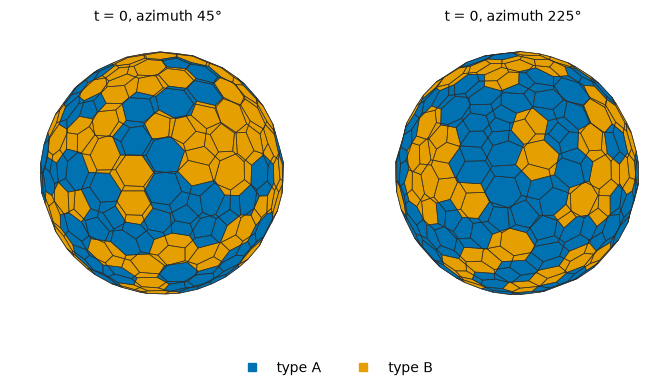

In [3]:
from tyssue.draw.plt_draw import sheet_view_3d, patch_2d_collections_to_3d
from tyssue import config as tyssue_draw_config


def face_rgba(eptm):
    """(Nf, 4) RGBA, one row per face, from its ``cell_type``."""
    return np.array([mcolors.to_rgba(CELL_TYPE_COLORS[t]) for t in eptm.face_df["cell_type"]])


def sphere_draw_specs():
    """Draw spec shared by the stills and the movie: filled faces, thin dark
    junctions, no vertex markers."""
    specs = tyssue_draw_config.draw.sheet_spec()
    specs["face"]["visible"] = True
    specs["face"]["alpha"] = 1.0
    specs["vert"]["visible"] = False
    specs["edge"]["visible"] = True
    specs["edge"]["color"] = "#2b2b2b"
    specs["edge"]["width"] = 0.5
    return specs


def draw_sphere(eptm, ax=None, title=None, view_angle=(22, 45), half=None):
    """Draw one epithelium as a coloured sphere on an Axes3D.

    `half` fixes the half-width of the axes box; pass the same value to several
    panels to draw them all at the same scale."""
    specs = sphere_draw_specs()
    specs["face"]["color"] = face_rgba(eptm)
    if ax is None:
        fig = plt.figure(figsize=(4.2, 4.2))
        ax = fig.add_subplot(111, projection="3d")
    _, ax = sheet_view_3d(eptm, coords=COORDS, ax=ax, view_angle=view_angle, **specs)
    patch_2d_collections_to_3d(ax)
    # Set the box explicitly rather than leaving it to matplotlib's autoscale: equal
    # ranges about the tissue centre, so the sphere is drawn undistorted and every
    # panel is on the same scale. `zoom` reclaims the room an Axes3D reserves for the
    # axes furniture we are about to switch off.
    pos = eptm.vert_df[COORDS].to_numpy(dtype=float)
    centre = pos.mean(axis=0)
    if half is None:
        half = float(np.abs(pos - centre).max()) * 1.02
    ax.set(xlim=(centre[0] - half, centre[0] + half),
           ylim=(centre[1] - half, centre[1] + half),
           zlim=(centre[2] - half, centre[2] + half))
    ax.set_box_aspect((1, 1, 1), zoom=1.45)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax


# One half-width for every panel in the notebook, taken from the starting sphere, so
# the stills further down are all drawn at the same scale.
HALF_SPAN = float(np.abs(sheet.vert_df[COORDS].to_numpy(dtype=float)).max()) * 1.05

fig = plt.figure(figsize=(8.4, 4.2))
for i, azim in enumerate((45, 225)):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    draw_sphere(sheet, ax=ax, title=f"t = 0, azimuth {azim}°", view_angle=(22, azim),
                half=HALF_SPAN)
handles = [plt.Line2D([], [], marker="s", ls="", color=c, label=f"type {t}")
           for t, c in CELL_TYPE_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)
fig.savefig(OUT_DIR / "initial_condition.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## Step 2 — the parameters, set explicitly

Every number the simulation uses is named here once, so the config dicts below read as
assignments rather than as magic constants.

The mechanical parameters are in the usual non-dimensional vertex-model units, scaled by
$K_A A_0^2$ (`ref_effector = "FaceAreaElasticity"`):

* $K_A = 1$, $A_0 = 1$ — the reference scale, matching the mesh built above.
* $K_P = 0.1$, $P_0 = 3.72 \approx \sqrt{8\sqrt3}$ — the perimeter of a regular hexagon of
  unit area, so a relaxed regular cell sits at the bottom of both elastic wells at once.
* $\Lambda_\mathrm{homo} = 0.05$, $\Lambda_\mathrm{het} = 0.45$ — the differential
  adhesion. Only the *contrast* $\Lambda_\mathrm{het}-\Lambda_\mathrm{homo}$ drives
  sorting; the common part just shifts the effective preferred perimeter of every cell
  equally.
* $K_V = 0.05$, $V_0 = $ the volume the generated mesh already encloses. Soft enough not
  to fight the in-surface mechanics, stiff enough that the vesicle keeps its size.

The topology parameters matter as much as the mechanics, because sorting *is* T1
transitions:

* `threshold_length = 0.08` — about an eighth of the initial mean junction length, so
  only genuinely collapsing junctions merge. Larger values (0.15+) do sort faster, but
  they also start producing duplicated `(srce, trgt)` half-edge pairs, i.e. a degenerate
  mesh.
* `p_4 = 5.0`, `p_5p = 0.5` — the per-unit-time probabilities that a rank-4 / rank-5+
  vertex detaches again, completing the exchange. tyssue's defaults (0.1 and 0.01) leave
  four-fold vertices sitting unresolved for tens of time units, which throttles sorting
  far below what the tension contrast would allow.

In [4]:
# --- mechanics -------------------------------------------------------------
AREA_ELASTICITY = 1.0        # K_A
PREFERED_AREA = 1.0          # A_0
PERIMETER_ELASTICITY = 0.1   # K_P
PREFERED_PERIMETER = 3.72    # P_0 ~ sqrt(8 sqrt(3)), a unit-area regular hexagon
LAMBDA_HOMO = 0.05           # line tension on an A|A or B|B junction
LAMBDA_HET = 0.45            # line tension on an A|B junction  (> LAMBDA_HOMO)
LUMEN_VOL_ELASTICITY = 0.1  # K_V
# K_S: the surface smoother. Strictly a trade-off against sorting (see the sweep at the
# end): 0 leaves ~19 everted vertices and S(120) = 0.71; 0.5 removes eversion entirely
# but freezes the mesh and sorting stops. 0.05 keeps the sorting clearly above the
# control while measurably damping the spikes.
SURFACE_ELASTICITY = 0.2  # K_S
VISCOSITY = 1.0              # eta

# --- topology (T1 transitions) --------------------------------------------
THRESHOLD_LENGTH = 0.08      # junctions shorter than this merge their two vertices
P_4 = 5.0                    # per unit time: a rank-4 vertex detaches again
P_5P = 0.5                   # per unit time: a rank-5+ vertex detaches

# --- integration -----------------------------------------------------------
DT = 0.05                    # solver / emit interval
TF = 200.0                   # total simulated time  (TF / DT = 2400 steps)

params = pd.Series({
    "K_A  area_elasticity": AREA_ELASTICITY,
    "A_0  prefered_area": PREFERED_AREA,
    "K_P  perimeter_elasticity": PERIMETER_ELASTICITY,
    "P_0  prefered_perimeter": PREFERED_PERIMETER,
    "L_homo  homotypic tension": LAMBDA_HOMO,
    "L_het   heterotypic tension": LAMBDA_HET,
    "K_V  lumen_vol_elasticity": LUMEN_VOL_ELASTICITY,
    "V_0  lumen_prefered_vol": LUMEN_VOL_0,
    "K_S  surface_elasticity": SURFACE_ELASTICITY,
    "d_0  prefered_deviation": DEVIATION_0,
    "eta  viscosity": VISCOSITY,
    "l_min  threshold_length": THRESHOLD_LENGTH,
    "p_4": P_4,
    "p_5p": P_5P,
    "dt": DT,
    "t_f": TF,
}, name="value")
params.to_frame()

,value
K_A area_elasticity,1.000000
A_0 prefered_area,1.000000
K_P perimeter_elasticity,0.100000
P_0 prefered_perimeter,3.720000
L_homo homotypic tension,0.050000
L_het heterotypic tension,0.450000
K_V lumen_vol_elasticity,0.100000
V_0 lumen_prefered_vol,270.205372
K_S surface_elasticity,0.200000
d_0 prefered_deviation,0.071563


## Step 3 — the `EulerSolver` configuration

Each key of the config is filled in explicitly below.

* `eptm` / `tissue_type` — the mesh written in step 1, loaded as a tyssue `Sheet`.
* `geom: "ClosedSheetGeometry"` — the closed 2.5-D geometry: everything
  `SheetGeometry` does, plus the enclosed volume in `settings["lumen_vol"]`.
* `effectors` — the four requested terms. `ref_effector` picks the one used to
  non-dimensionalise the energy.
* `parameters` — written straight into the element dataframes at start-up, so this is
  where $K_A, A_0, K_P, P_0, \eta$ live. Two edge columns deserve a note:
  * `line_tension` is seeded at $\Lambda_\mathrm{homo}$, but from the first step onward it
    is owned entirely by the `differential_adhesion` behavior.
  * `heterotypic` is declared here **only so that the column exists when the solver
    builds its `History`** — tyssue's `History` fixes its column list at construction, so
    a column created later by a behavior would never be recorded. The behavior stamps the
    0/1 classification into it each step, which gives us a recorded cross-check for the
    sorting index computed independently from the topology further down.
* `settings` — the T1 knobs plus the two lumen parameters. `LumenVolumeElasticity` is the
  one effector whose parameters are `settings` entries rather than dataframe columns.
* `auto_reconnect: True` — arm tyssue's `reconnect` behavior (merge short junctions,
  detach high-rank vertices). **Cell sorting is impossible without it.**
* `history_columns` — record only what the analysis and the movie need. The solver always
  adds the coordinates and the `srce`/`trgt`/`face` topology, so the recorded history is
  enough to rebuild the mesh at any frame.
* `backend: "python"` — the Rust kernels cover `SheetGeometry` and the three standard
  sheet effectors; a closed sheet with a lumen term is outside that, so the Python path
  is the honest choice here.

In [5]:
tyssue_config = {
    "name": "Sorting Sphere",
    "eptm": str(MESH_PATH),
    "tissue_type": "Sheet",

    # Written into the element dataframes when the solver starts.
    "parameters": {
        "face_df": {
            "area_elasticity": AREA_ELASTICITY,
            "prefered_area": PREFERED_AREA,
            "perimeter_elasticity": PERIMETER_ELASTICITY,
            "prefered_perimeter": PREFERED_PERIMETER,
            "is_alive": 1.0,
        },
        "edge_df": {
            # Seed value only — the behavior owns this column from step 1 onward.
            "line_tension": LAMBDA_HOMO,
            "is_active": 1.0,
            # Must exist now so that History records it (see the note above).
            "heterotypic": 0.0,
        },
        "vert_df": {
            "viscosity": VISCOSITY,
            "is_active": 1.0,
            # SurfaceElasticity's two parameters. dev_length and (dx, dy, dz) are
            # written by the geometry below, not set here.
            "surface_elasticity": SURFACE_ELASTICITY,
            "prefered_deviation": DEVIATION_0,
        },
    },

    # ClosedSheetGeometry + the one-ring deviation columns SurfaceElasticity reads
    # (vivarium_tyssue/geometry/vert_deviation.py).
    "geom": "ClosedSheetVertDeviationGeometry",
    "effectors": [
        "FaceAreaElasticity",
        "PerimeterElasticity",
        "LineTension",
        "LumenVolumeElasticity",
        "SurfaceElasticity",
    ],
    "ref_effector": "FaceAreaElasticity",
    "factory": "model_factory",

    # T1 knobs (read by tyssue's `reconnect`) + the two LumenVolumeElasticity parameters,
    # which are `settings` entries rather than dataframe columns.
    "settings": {
        "threshold_length": THRESHOLD_LENGTH,
        "p_4": P_4,
        "p_5p": P_5P,
        "lumen_vol_elasticity": LUMEN_VOL_ELASTICITY,
        "lumen_prefered_vol": LUMEN_VOL_0,
    },

    "auto_reconnect": True,          # T1 transitions — sorting is impossible without this
    "check_intersections": False,
    "intersection_options": {},
    "bounds": {},
    "output_columns": {},

    # Record only what the movie and the analysis need (coords and srce/trgt/face are
    # always added on top of these).
    "history_columns": {
        "vert_df": ["dev_length"],
        "edge_df": ["line_tension", "heterotypic", "length"],
        "face_df": ["cell_type", "area", "perimeter"],
    },

    "maps": {},
    "backend": "python",             # ClosedSheetGeometry + lumen is outside the Rust kernels
    "substeps": 1,
    "max_displacement": 0.0,
    "record_history": True,
}

pprint(tyssue_config, sort_dicts=False, width=96)

{'name': 'Sorting Sphere',
 'eptm': '/Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/data/sphere_200.hf5',
 'tissue_type': 'Sheet',
 'parameters': {'face_df': {'area_elasticity': 1.0,
                            'prefered_area': 1.0,
                            'perimeter_elasticity': 0.1,
                            'prefered_perimeter': 3.72,
                            'is_alive': 1.0},
                'edge_df': {'line_tension': 0.05, 'is_active': 1.0, 'heterotypic': 0.0},
                'vert_df': {'viscosity': 1.0,
                            'is_active': 1.0,
                            'surface_elasticity': 0.2,
                            'prefered_deviation': 0.07156314964080458}},
 'geom': 'ClosedSheetVertDeviationGeometry',
 'effectors': ['FaceAreaElasticity',
               'PerimeterElasticity',
               'LineTension',
               'LumenVolumeElasticity',
               'SurfaceElasticity'],
 'ref_effector': 'FaceAreaElastic

## Step 4 — the `DifferentialAdhesion` configuration

Four numbers and two column names. Note what is *not* here: any per-edge data. The
process never enumerates junctions — it states the rule, and the behavior applies it to
whatever mesh exists at the time.

`apply_boundary_tension` covers the open-sheet case (half-edges with no opposite, on a
free border). A closed sphere has none, so it stays off.

In [6]:
adhesion_config = {
    "homotypic_tension": LAMBDA_HOMO,
    "heterotypic_tension": LAMBDA_HET,
    "type_column": "cell_type",       # the face_df column holding the cell type
    "boundary_tension": 0.0,          # unused on a closed sheet ...
    "apply_boundary_tension": False,  # ... so leave it off
    "record_column": "heterotypic",   # edge_df column stamped with the 0/1 classification
}

pprint(adhesion_config, sort_dicts=False)

{'homotypic_tension': 0.05,
 'heterotypic_tension': 0.45,
 'type_column': 'cell_type',
 'boundary_tension': 0.0,
 'apply_boundary_tension': False,
 'record_column': 'heterotypic'}


## Step 5 — the composite spec

Two processes and four stores. The processes never call each other; they are coupled
only through shared state:

* **`Tissue State`** — the tyssue `vert` / `edge` / `face` dataframes, written by the
  solver, read by `Adhesion`.
* **`Behaviors`** — the queue `Adhesion` writes its behavior node into and the solver
  drains on its next step. The solver's `behaviors_update` output wires back to the same
  store to clear it once consumed.
* **`global_time`** and **`Network Changed`** — the clock and the topology-changed flag.

Both processes run on the same `interval = DT`, so every Euler step is followed by a
fresh classification.

`build_spec` takes the heterotypic tension as its only argument: the **control** run is
the same spec with $\Lambda_\mathrm{het} = \Lambda_\mathrm{homo}$, which switches the
differential adhesion off while leaving every other part of the model — including the
process, the behavior and the T1 machinery — exactly as it is.

In [7]:
def build_spec(heterotypic_tension: float) -> dict:
    """The composite spec. `heterotypic_tension` is the only thing that differs
    between the sorting run and the control."""
    return {
        "Tyssue": {
            "_type": "process",
            "address": "local:EulerSolver",
            "config": deepcopy(tyssue_config),
            "inputs": {
                "behaviors": ["Behaviors"],
                "global_time": ["global_time"],
            },
            "outputs": {
                "datasets": ["Tissue State"],
                "network_changed": ["Network Changed"],
                "behaviors_update": ["Behaviors"],
            },
            "interval": DT,
        },
        "Adhesion": {
            "_type": "process",
            "address": "local:DifferentialAdhesion",
            "config": {**adhesion_config, "heterotypic_tension": heterotypic_tension},
            "inputs": {
                "datasets": ["Tissue State"],
            },
            "outputs": {
                "behaviors": ["Behaviors"],
            },
            "interval": DT,
        },
        "Network Changed": False,
        "Behaviors": {},
    }


spec = build_spec(LAMBDA_HET)

# Print the wiring without re-printing the solver config already shown above.
pprint({k: (v if k != "Tyssue" else {**v, "config": "<see above>"})
        for k, v in spec.items()}, sort_dicts=False, width=96)

{'Tyssue': {'_type': 'process',
            'address': 'local:EulerSolver',
            'config': '<see above>',
            'inputs': {'behaviors': ['Behaviors'], 'global_time': ['global_time']},
            'outputs': {'datasets': ['Tissue State'],
                        'network_changed': ['Network Changed'],
                        'behaviors_update': ['Behaviors']},
            'interval': 0.05},
 'Adhesion': {'_type': 'process',
              'address': 'local:DifferentialAdhesion',
              'config': {'homotypic_tension': 0.05,
                         'heterotypic_tension': 0.45,
                         'type_column': 'cell_type',
                         'boundary_tension': 0.0,
                         'apply_boundary_tension': False,
                         'record_column': 'heterotypic'},
              'inputs': {'datasets': ['Tissue State']},
              'outputs': {'behaviors': ['Behaviors']},
              'interval': 0.05},
 'Network Changed': False,
 'Behavio

## Step 6 — the bigraph

`bigraph_viz` draws the spec above with the manuscript palette (processes as boxes in
peach / pink, stores as circles in light blue; defined once in
`Experiments/bigraph_style.py`). The diagram is generated from the very spec that is
about to be run, so it cannot drift from the simulation.

In [8]:
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core

core = build_core()   # the core the simulation itself runs on

plot_experiment_bigraph(
    spec, core=core,
    filename="differential_adhesion_bigraph",
    out_dir=OUT_DIR,
)

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)
module `pbg_emitters.xarray_emitter` not found during dynamic import
wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/outputs/differential_adhesion_bigraph.png


## Step 7 — run

Two runs from the identical mesh and seed: the sorting run
($\Lambda_\mathrm{het} = 0.45$) and the control ($\Lambda_\mathrm{het} =
\Lambda_\mathrm{homo} = 0.05$, i.e. uniform tension).

Aggressive T1 activity can leave the mesh with transiently duplicated `(srce, trgt)`
half-edge pairs, which tyssue reports as a warning from `get_opposite`. It is noisy
rather than informative at this rate, so it is silenced for the run and the mesh
integrity is checked explicitly afterwards.

Seeding `numpy` fixes the mesh and the labelling, but **not** the trajectory: tyssue's
`EventManager.update` calls `random.shuffle` on the stdlib RNG, which nothing here seeds,
and `detach_vertices` draws from it. Re-running moves the final sorting index by a
percentage point or so. Compare aggregates, not exact numbers.

In [9]:
from process_bigraph import Composite


def run(heterotypic_tension: float, label: str, tf: float = TF):
    """Run one composite and return its (Composite, tyssue History)."""
    np.random.seed(SEED)   # T1 detachment is stochastic; fix it per run
    sim = Composite({"state": build_spec(heterotypic_tension)}, core=core)
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Duplicated")
        sim.run(tf)
    elapsed = time.time() - t0
    history = sim.state["Tyssue"]["instance"].history
    history.update_datasets()
    eptm = sim.state["Tyssue"]["instance"].eptm
    print(f"[{label}] L_het={heterotypic_tension:g}  {elapsed:.0f}s  "
          f"{len(list(history.time_stamps))} frames  "
          f"Nf={eptm.Nf} Nv={eptm.Nv} Ne={eptm.Ne}  "
          f"lumen={eptm.settings['lumen_vol']:.1f} (V_0={LUMEN_VOL_0:.1f})")
    return sim, history


sim, history = run(LAMBDA_HET, "sorting")
sim_control, history_control = run(LAMBDA_HOMO, "control")

[sorting] L_het=0.45  58s  3999 frames  Nf=200 Nv=396 Ne=1188  lumen=268.6 (V_0=270.2)
[control] L_het=0.05  60s  3999 frames  Nf=200 Nv=396 Ne=1188  lumen=269.7 (V_0=270.2)


The mesh survives the run: no duplicated half-edge pairs, no degenerate (fewer than
three-sided) faces, and the cell count is unchanged — there are no divisions or deaths
in this model, only rearrangement.

`max_over_mean_radius` and `verts_past_1.1x_mean_radius` are the numbers to watch: they
count **eversion**, cells squeezed between high-tension heterotypic junctions and pushed
outward by the lumen pressure into radial spikes. `SurfaceElasticity` is what damps them,
and `mean_dev_length` reports the roughness it acts on (the starting sphere sits at
`DEVIATION_0`, printed above).

The control has no eversion at all — uniform tension never squeezes a cell that way — so
the comparison also shows that the smoother is not what keeps the control smooth.

In [10]:
def mesh_report(sim, label):
    eptm = sim.state["Tyssue"]["instance"].eptm
    dup = pd.MultiIndex.from_arrays(
        [eptm.edge_df["srce"], eptm.edge_df["trgt"]]).duplicated().sum()
    sides = eptm.edge_df.groupby("face").size()
    pos = eptm.vert_df[COORDS].to_numpy(dtype=float)
    radius = np.linalg.norm(pos - pos.mean(axis=0), axis=1)
    update_vert_deviation(eptm)
    return {
        "run": label,
        "cells": eptm.Nf,
        "verts": eptm.Nv,
        "half_edges": eptm.Ne,
        "duplicate_srce_trgt": int(dup),
        "min_polygon_sides": int(sides.min()),
        "mean_area": round(float(eptm.face_df["area"].mean()), 4),
        "mean_perimeter": round(float(eptm.face_df["perimeter"].mean()), 4),
        "lumen_vol": round(float(eptm.settings["lumen_vol"]), 2),
        "positions_finite": bool(np.isfinite(eptm.vert_df[COORDS].to_numpy()).all()),
        # how far the most-displaced vertex sits from the mean radius (see note below)
        "max_over_mean_radius": round(float(radius.max() / radius.mean()), 3),
        "verts_past_1.1x_mean_radius": int((radius > 1.1 * radius.mean()).sum()),
        "mean_dev_length": round(float(eptm.vert_df["dev_length"].mean()), 4),
        "max_dev_length": round(float(eptm.vert_df["dev_length"].max()), 4),
    }


pd.DataFrame([mesh_report(sim, "sorting"), mesh_report(sim_control, "control")]).set_index("run").T

run,sorting,control
cells,200,200
verts,396,396
half_edges,1188,1188
duplicate_srce_trgt,0,0
min_polygon_sides,4,4
mean_area,1.0342,1.0154
mean_perimeter,4.0877,3.8166
lumen_vol,268.57,269.71
positions_finite,True,True
max_over_mean_radius,1.183,1.025


## Step 8 — the movie

`create_gif_3d` walks the recorded `History`, rebuilding the epithelium at each sampled
frame and drawing it into a fixed 3-D axes box. Two details make it come out right:

* the recorded history holds vertex **positions** and topology, not the derived edge
  geometry, so each frame's geometry is recomputed with `ClosedSheetGeometry.update_all`
  before it is drawn;
* face colours are handed in through `dynamic_draw_kwds`, which is re-evaluated per
  frame — necessary because the number of faces (and, after a T1, which face is which)
  can change between frames.

`create_gif_3d` occasionally reports `Dropped frame N`: a frame where an everted cell
(see above) pushes an axis range to infinity and matplotlib refuses to draw it. It skips
that one frame and carries on, so the animation is 79 frames instead of 80.

In [11]:
from tyssue.draw import create_gif_3d

GIF_FRAMES = 80


def frame_kwds(eptm):
    """Per-frame draw kwds. Also refreshes the derived geometry: the History stores
    positions + topology, not the edge/face geometry columns the drawing reads."""
    ClosedSheetGeometry.update_all(eptm)
    return {"face": {"color": face_rgba(eptm)}}


def render_gif(history, out_path: Path, view_angle=(22, 45)):
    specs = sphere_draw_specs()
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        create_gif_3d(
            history, str(out_path),
            num_frames=GIF_FRAMES, dpi=GIF_DPI, coords=COORDS,
            view_angle=view_angle,
            dynamic_draw_kwds=[frame_kwds],
            **specs,
        )
    # create_gif_3d closes each frame's figure only on the happy path — a dropped
    # frame leaves its half-built figure open, and the notebook's post-execute hook
    # then tries to render it (and can trip over the degenerate axes that made the
    # frame fail in the first place). Discard anything left behind.
    plt.close("all")
    print(f"wrote {out_path} ({out_path.stat().st_size / 1e6:.1f} MB)")
    return out_path


gif_path = render_gif(history, OUT_DIR / "cell_sorting.gif")

Dropped frame 50
cannot convert float NaN to integer
wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/outputs/cell_sorting.gif (3.1 MB)


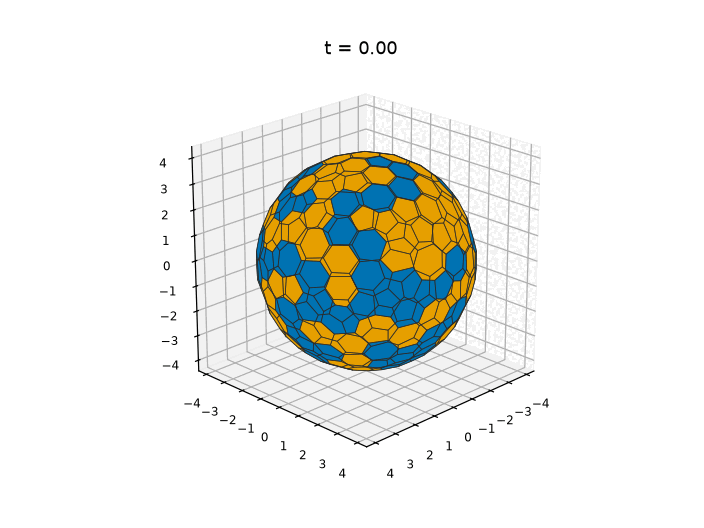

In [12]:
from IPython.display import Image, display

display(Image(filename=str(gif_path)))

The same rendering for the control, for comparison — uniform tension, the same T1
machinery, and the pattern stays mixed.

wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/differential_adhesion/outputs/cell_sorting_control.gif (3.1 MB)


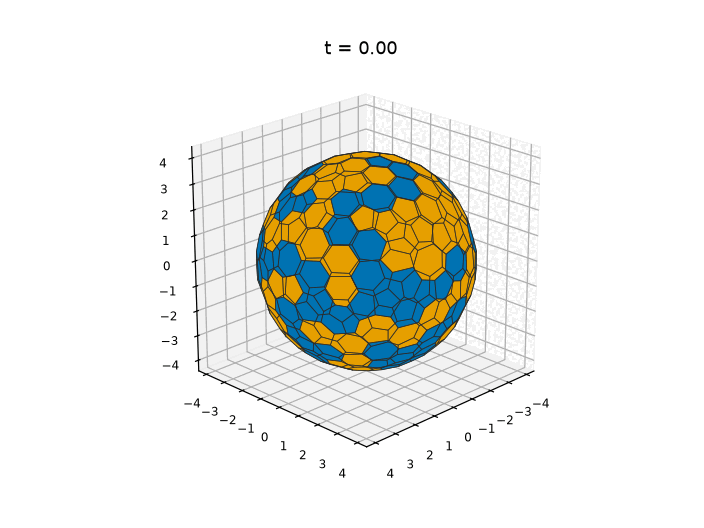

In [13]:
gif_control = render_gif(history_control, OUT_DIR / "cell_sorting_control.gif")
display(Image(filename=str(gif_control)))

Start and end, side by side.

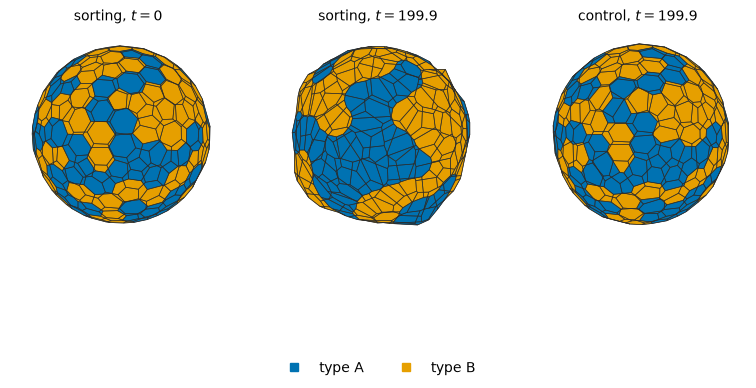

In [14]:
t_last = float(list(history.time_stamps)[-1])

fig = plt.figure(figsize=(9.5, 5.0))
panels = [
    (history, 0.0, "sorting, $t = 0$"),
    (history, t_last, f"sorting, $t = {t_last:g}$"),
    (history_control, t_last, f"control, $t = {t_last:g}$"),
]
for i, (h, t, title) in enumerate(panels):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    frame = h.retrieve(t)
    ClosedSheetGeometry.update_all(frame)
    draw_sphere(frame, ax=ax, title=title, half=HALF_SPAN)
handles = [plt.Line2D([], [], marker="s", ls="", color=c, label=f"type {t}")
           for t, c in CELL_TYPE_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)
fig.savefig(OUT_DIR / "start_end.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## Step 9 — the sorting index

$S(t)$ is computed **from the recorded topology**, not from the tension the behavior
wrote: for each frame we take the `srce`/`trgt`/`face` columns of `edge_df` and the
`cell_type` column of `face_df`, pair each half-edge $(s,t)$ with its opposite $(t,s)$,
and compare the two faces' types. That makes the metric an independent measurement of the
state rather than a read-back of the input — and it is defined at $t = 0$, before the
behavior has run at all.

Reading the metric:

* $S \approx 0.5$ — randomly mixed (each of a cell's ~6 neighbours is the other type with
  probability $\tfrac12$).
* $S \to 1$ — fully sorted; only the ring where the two caps meet is heterotypic. For 200
  cells in two hemispherical caps that ring is roughly $2\pi R / \bar\ell \approx 40$
  junctions out of ~600, so the reachable ceiling is around $S \approx 0.93$, not 1.

In [15]:
def _opposite_positional(srce, trgt):
    """Positional index of each half-edge's opposite, -1 where there is none.
    Same rule the `differential_adhesion` behavior uses, recomputed here from the
    recorded topology so the metric is independent of what the behavior wrote."""
    forward = pd.Series(np.arange(len(srce)), index=pd.MultiIndex.from_arrays([srce, trgt]))
    forward = forward[~forward.index.duplicated(keep="first")]
    opposite = forward.reindex(pd.MultiIndex.from_arrays([trgt, srce])).to_numpy()
    return np.where(np.isnan(opposite), -1, np.nan_to_num(opposite)).astype(int)


def interface_metrics(history, stride: int = 1, t_max=None) -> pd.DataFrame:
    """Per-frame junction classification, computed from the recorded mesh.

    Returns the sorting index and the counts it is built from, the total length of
    heterotypic interface, a hash of the frame's connectivity (which changes exactly
    on the steps a T1 fired), and — for the cross-check below — the same index
    derived from the 0/1 flag the behavior stamped into ``edge_df``.
    """
    edge = history.datasets["edge"]
    face = history.datasets["face"]
    if t_max is not None:
        edge = edge[edge["time"] <= t_max]
        face = face[face["time"] <= t_max]
    face_groups = dict(tuple(face.groupby("time")))
    rows = []
    for i, (t, e) in enumerate(edge.groupby("time")):
        if i % stride:
            continue
        types = face_groups[t].set_index("face")["cell_type"]
        own = types.reindex(e["face"].to_numpy()).to_numpy()
        opp = _opposite_positional(e["srce"].to_numpy(), e["trgt"].to_numpy())
        has_opp = opp >= 0
        hetero = has_opp & (own != own[np.where(has_opp, opp, 0)])
        lengths = e["length"].to_numpy()
        n = len(e)
        rows.append({
            "time": float(t),
            # halved throughout: each junction is stored as two half-edges
            "n_junctions": n // 2,
            "n_heterotypic": int(hetero.sum()) // 2,
            "sorting_index": 1.0 - hetero.sum() / n,
            "heterotypic_length": float(lengths[hetero].sum()) / 2,
            "total_length": float(lengths.sum()) / 2,
            # the behavior's own 0/1 stamp, for the cross-check below
            "recorded_sorting_index": 1.0 - float(e["heterotypic"].mean()),
            # changes exactly when the mesh connectivity does, i.e. on a T1 step
            "topology_hash": int(pd.util.hash_pandas_object(
                e[["srce", "trgt", "face"]], index=False).sum()),
        })
    return pd.DataFrame(rows)


STRIDE = 4   # ~600 points out of 2400 frames; set to 1 for every frame
si = interface_metrics(history, stride=STRIDE)
si_control = interface_metrics(history_control, stride=STRIDE)

si.to_csv(OUT_DIR / "sorting_index.csv", index=False)
si_control.to_csv(OUT_DIR / "sorting_index_control.csv", index=False)
si.head()

,time,n_junctions,n_heterotypic,sorting_index,heterotypic_length,total_length,recorded_sorting_index,topology_hash
0,0.0,594,301,0.493266,189.412553,374.223976,1.000000,3357758887348063378
1,0.2,594,301,0.493266,179.666054,376.965909,0.493266,3357758887348063378
2,0.4,594,301,0.493266,166.727704,381.187328,0.493266,3357758887348063378
3,0.6,594,301,0.493266,159.231068,385.134243,0.493266,3357758887348063378
4,0.8,593,300,0.494098,154.424644,388.135115,0.494098,12829248189115793165


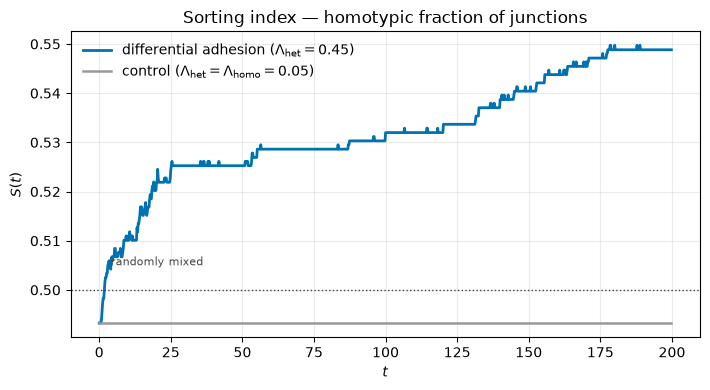

sorting  S(0) = 0.493   S(200) = 0.549
control  S(0) = 0.493   S(200) = 0.493
heterotypic junctions: 301 -> 268 (of 594 junctions)


In [16]:
T_LABEL = r"$t$"
S_LABEL = r"$S(t)$"

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(si["time"], si["sorting_index"], lw=2, color="#0072B2",
        label=rf"differential adhesion ($\Lambda_\mathrm{{het}}={LAMBDA_HET:g}$)")
ax.plot(si_control["time"], si_control["sorting_index"], lw=1.8, color="#999999",
        label=rf"control ($\Lambda_\mathrm{{het}}=\Lambda_\mathrm{{homo}}={LAMBDA_HOMO:g}$)")
ax.axhline(0.5, ls=":", lw=1.0, color="#444444")
ax.annotate("randomly mixed", xy=(TF * 0.02, 0.505), fontsize=8, color="#444444")
ax.set_xlabel(T_LABEL)
ax.set_ylabel(S_LABEL)
ax.set_title("Sorting index — homotypic fraction of junctions")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "sorting_index.png", dpi=FIG_DPI)
plt.show()

print(f"sorting  S(0) = {si['sorting_index'].iloc[0]:.3f}   "
      f"S({TF:g}) = {si['sorting_index'].iloc[-1]:.3f}")
print(f"control  S(0) = {si_control['sorting_index'].iloc[0]:.3f}   "
      f"S({TF:g}) = {si_control['sorting_index'].iloc[-1]:.3f}")
print(f"heterotypic junctions: {si['n_heterotypic'].iloc[0]} -> "
      f"{si['n_heterotypic'].iloc[-1]} "
      f"(of {si['n_junctions'].iloc[-1]} junctions)")

### Cross-check against the behavior's own classification

The behavior stamps its 0/1 verdict into `edge_df["heterotypic"]` and that column is
recorded too, so the topology-derived metric above can be checked against it directly.
They agree on all but a small minority of frames — and those disagreements are not noise,
they have a single mechanical explanation worth spelling out.

`EventManager.update()` **shuffles** its queue (`random.shuffle(self.next)`), so within
one solver step the two queued behaviors — tyssue's `reconnect`, which performs the T1
surgery, and our `differential_adhesion` — run in a random order. On roughly half the
steps where a T1 fires, the classification is therefore computed just *before* that
step's rewiring, while the topology recorded for the frame is the one *after* it. The
recorded flag is then one step (0.05 time units) behind the mesh, and the behavior brings
it back in line on the very next step.

The check below confirms exactly that: apart from the two warm-up frames at the start of
the run — where `Adhesion` has not yet put anything into the `Behaviors` store, so the
column still holds its configured default — **every** disagreement lands on a frame whose
connectivity changed. Nothing disagrees on a frame where the mesh stood still.

This is also why the analysis uses the independently computed index: it is defined at
$t = 0$, and it never lags the mesh.

In [17]:
# Frame by frame (stride 1) over the first stretch of the run, where T1 activity is
# highest; t_max keeps the cell quick.
window = interface_metrics(history, stride=1, t_max=20.0)

disagrees = (window["sorting_index"] - window["recorded_sorting_index"]).abs() > 1e-9
topology_changed = window["topology_hash"] != window["topology_hash"].shift()
topology_changed.iloc[0] = False          # nothing to compare the first frame against

print(f"frames examined                         {len(window)}")
print(f"  frames where the mesh was rewired     {int(topology_changed.sum())}")
print(f"  frames where the two indices differ   {int(disagrees.sum())}")
print(f"    ... of which on a rewired frame     {int((disagrees & topology_changed).sum())}")
unexplained = window.loc[disagrees & ~topology_changed, "time"]
print(f"    ... on an unchanged mesh            {len(unexplained)}"
      f"   (times: {[round(t, 2) for t in unexplained]})")

window.loc[disagrees, ["time", "n_junctions", "sorting_index",
                       "recorded_sorting_index"]].head()

frames examined                         400
  frames where the mesh was rewired     107
  frames where the two indices differ   23
    ... of which on a rewired frame     21
    ... on an unchanged mesh            2   (times: [0.0, 0.05])


,time,n_junctions,sorting_index,recorded_sorting_index
0,0.00,594,0.493266,1.000000
1,0.05,594,0.493266,1.000000
22,1.10,593,0.497470,0.496627
41,2.05,592,0.501689,0.503378
45,2.25,592,0.501689,0.502534


### Where the interface went

The same sorting seen as the *amount* of `A|B` interface — the total length of
heterotypic junctions. This is the quantity the energy actually penalises, so it is the
more direct statement of what the model minimises; the sorting index is its dimensionless
count-based counterpart.

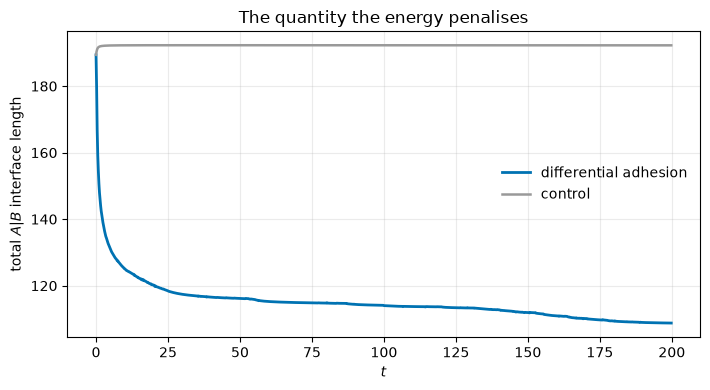

In [18]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(si["time"], si["heterotypic_length"], lw=2, color="#0072B2",
        label="differential adhesion")
ax.plot(si_control["time"], si_control["heterotypic_length"], lw=1.8, color="#999999",
        label="control")
ax.set_xlabel(T_LABEL)
ax.set_ylabel(r"total $A|B$ interface length")
ax.set_title("The quantity the energy penalises")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "heterotypic_length.png", dpi=FIG_DPI)
plt.show()

### What the smoother costs

`SurfaceElasticity` is not a free improvement, and the notebook is set up so you can see
the price. The plot below tracks the mean one-ring deviation $\bar\delta(t)$ — the
roughness the term acts on — for both runs.

Sweeping $K_S$ over a full 120-time-unit run (with $\delta_0$ fixed at the starting
sphere's value) gives a strictly **monotone trade-off**: every increase in smoothness is
paid for in sorting. (One run per row, so the same few-percent run-to-run spread noted
above applies.)

| $K_S$ | $S(120)$ | max/mean radius | everted vertices |
|---|---|---|---|
| 0 (off)   | **0.708** | 1.371 | 19 |
| 0.02      | 0.657 | 1.382 | 19 |
| **0.05**  | **0.630** | **1.298** | **17** |
| 0.1       | 0.581 | 1.258 | 14 |
| 0.2       | 0.534 | 1.179 | 11 |
| 0.5       | 0.502 (no sorting) | 1.084 | **0** |

There is no window where the spikes go away and the sorting survives, and the reason is
in the quantity itself: $\delta_i$ mixes **out-of-plane bulge** (what we want to punish)
with **in-plane irregularity of the one-ring** (what sorting legitimately produces — the
tissue's mean perimeter rises from 3.73 to 4.17 as the domains coarsen). A symmetric
quadratic well on $\delta$ cannot tell them apart, so a $K_S$ stiff enough to flatten a
spike is also stiff enough to pin the vertices a T1 has to move.

The plot above makes that concrete. The **control** has no eversion whatever — its
max/mean radius is 1.016 and not one vertex is displaced — and it still settles at
$\bar\delta \approx 0.15$, twice the starting sphere's $0.072$. That entire excess is
in-plane: it is the vertex model relaxing the Voronoi tiling into its own equilibrium
cell shapes. Any $\delta_0$ near $0.072$ is therefore already fighting a perfectly smooth
tissue before a single cell has everted.

Re-centring the well does not rescue it. The sorted tissue settles at
$\bar\delta \approx 0.31$ against the starting sphere's $0.072$, so putting $\delta_0$
up there ought to make the bulk feel nothing and leave only the tail (a spike reaches
$\delta \approx 1.15$). Measured, it fails in both directions, and the failures are
diagnostic:

| $\delta_0$ | $K_S$ | $S(120)$ | max/mean radius | everted vertices |
|---|---|---|---|---|
| 0.072 | 0.5 | 0.502 | 1.084 | 0 |
| 0.31  | 0.5 | 0.554 | 1.226 | 24 |
| 0.31  | 1.0 | 0.515 | 1.149 | 19 |
| 0.46  | 1.0 | **0.720** | 1.345 | **28** |

At $\delta_0 = 0.46$ the sorting is untouched — and the eversion is *worse* than with the
term switched off, because a well centred above the local roughness pushes the smooth
regions outward. The term is a spring toward a target roughness, not a one-sided penalty
on bulging, so it can only ever trade one for the other.

$K_S = 0.05$ is the default here: sorting stays far above the control ($0.63$ vs $0.50$)
while the eversion metrics improve. Raise it if a smooth surface matters more than the
sorting rate; set it to $0$ to recover the original run exactly.

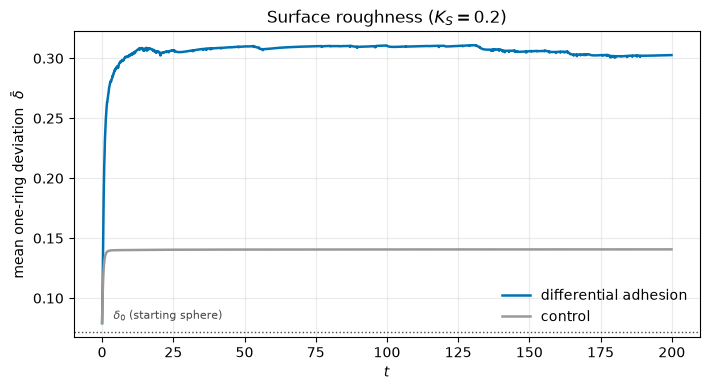

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for hist, label, colour in ((history, "differential adhesion", "#0072B2"),
                            (history_control, "control", "#999999")):
    vert = hist.datasets["vert"]
    rough = vert.groupby("time")["dev_length"].mean()
    ax.plot(rough.index, rough.to_numpy(), lw=1.8, color=colour, label=label)
ax.axhline(DEVIATION_0, ls=":", lw=1.0, color="#444444")
ax.annotate(r"$\delta_0$ (starting sphere)", xy=(TF * 0.02, DEVIATION_0 * 1.15),
            fontsize=8, color="#444444")
ax.set_xlabel(T_LABEL)
ax.set_ylabel(r"mean one-ring deviation  $\bar\delta$")
ax.set_title(rf"Surface roughness ($K_S = {SURFACE_ELASTICITY:g}$)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "roughness.png", dpi=FIG_DPI)
plt.show()

The sweep above is reproducible here. It is off by default because it is six more full
runs (~5 minutes); set `RUN_SURFACE_SWEEP = True` to regenerate the table.

In [20]:
RUN_SURFACE_SWEEP = False

if RUN_SURFACE_SWEEP:
    rows = []
    for k_s in [0.0, 0.02, 0.05, 0.1, 0.2, 0.5]:
        tyssue_config["parameters"]["vert_df"]["surface_elasticity"] = k_s
        sweep_sim, sweep_history = run(LAMBDA_HET, f"K_S={k_s:g}")
        eptm = sweep_sim.state["Tyssue"]["instance"].eptm
        pos = eptm.vert_df[COORDS].to_numpy(dtype=float)
        radius = np.linalg.norm(pos - pos.mean(axis=0), axis=1)
        rows.append({
            "K_S": k_s,
            "S(final)": round(interface_metrics(
                sweep_history, stride=len(list(sweep_history.time_stamps)) - 1
            )["sorting_index"].iloc[-1], 3),
            "max/mean radius": round(float(radius.max() / radius.mean()), 3),
            "everted verts": int((radius > 1.1 * radius.mean()).sum()),
        })
    tyssue_config["parameters"]["vert_df"]["surface_elasticity"] = SURFACE_ELASTICITY
    display(pd.DataFrame(rows).set_index("K_S"))
else:
    print("skipped — set RUN_SURFACE_SWEEP = True to regenerate the table above")

skipped — set RUN_SURFACE_SWEEP = True to regenerate the table above


## Summary

Starting from a 50:50 random mix on a closed 200-cell sphere, raising the line tension on
heterotypic junctions from $\Lambda_\mathrm{homo}=0.05$ to $\Lambda_\mathrm{het}=0.45$
drives the sorting index up from its random-mixture value of $\approx 0.5$, while the
control — identical model, identical T1 machinery, uniform tension — stays flat at
$0.5$ throughout. Sorting is still in progress when the run ends: $S(t)$ has not
plateaued, and running longer (or with a larger tension contrast) continues to coarsen
the two domains.

`SurfaceElasticity` damps the eversion the high heterotypic tension provokes, at a
measured cost in sorting rate — the trade-off is monotone, so the stiffness is a
deliberate choice rather than a tuning detail, and the section above shows the whole
curve.

Nothing in `EulerSolver` was changed. The whole model is one process
(`DifferentialAdhesion`) writing into the `Behaviors` store, one behavior
(`differential_adhesion`) that re-derives which junctions are heterotypic from the live
mesh on every step — so the tensions follow the topology through every T1 transition —
and one added geometry (`ClosedSheetVertDeviationGeometry`) supplying the columns
`SurfaceElasticity` reads.